# QUANT features + Extra Trees feature importance

Extract QUANT interval-quantile features from a time series classification dataset, train an `ExtraTreesClassifier` on them, then inspect feature importances.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from aeon.transformations.collection.interval_based import QUANTTransformer

from tscbench.utils import load_ucr_fold

DATASET = "ArrowHead"
FOLD = 0
RANDOM_STATE = 0

X_train, y_train, X_test, y_test = load_ucr_fold(DATASET, FOLD)
X_train.shape, X_test.shape

((36, 1, 251), (175, 1, 251))

## 1. Extract QUANT features

QUANT computes quantiles over a fixed dyadic set of intervals on the raw series and three transformations of it. The transform returns a dense `(n_cases, n_features)` array.

In [2]:
quant = QUANTTransformer()
F_train = quant.fit_transform(X_train, y_train)
F_test = quant.transform(X_test)

feature_names = [f"quant_{i}" for i in range(F_train.shape[1])]
print("train features:", F_train.shape)
print("test features: ", F_test.shape)

train features: (36, 2242)
test features:  (175, 2242)


## 2. Train Extra Trees

In [3]:
clf = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
clf.fit(F_train, y_train)

y_pred = clf.predict(F_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test accuracy: 0.8343


## 3. Feature importance

Extra Trees exposes mean impurity-decrease importances in `feature_importances_`.

In [4]:
import polars as pl

importances = clf.feature_importances_
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)

importance_df = (
    pl.DataFrame({
        "feature": feature_names,
        "importance": importances,
        "std": std,
    })
    .sort("importance", descending=True)
)
importance_df.head(20)

feature,importance,std
str,f64,f64
"""quant_2034""",0.007409,0.0448
"""quant_2184""",0.007234,0.045286
"""quant_477""",0.006988,0.049706
"""quant_942""",0.006924,0.04129
"""quant_930""",0.006517,0.044991
…,…,…
"""quant_2063""",0.004557,0.033826
"""quant_910""",0.004476,0.031968
"""quant_1256""",0.004397,0.035168


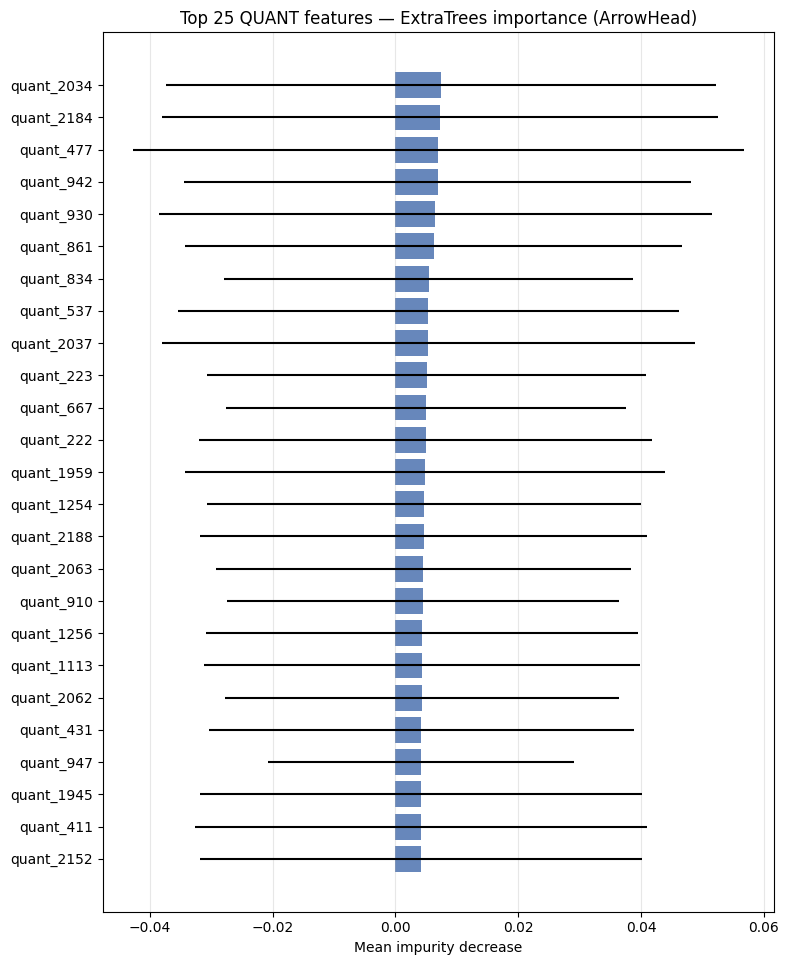

In [5]:
top_n = 25
top = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(8, 0.35 * top_n + 1))
y_pos = np.arange(top.height)[::-1]
ax.barh(
    y_pos,
    top["importance"].to_numpy(),
    xerr=top["std"].to_numpy(),
    color="#4C72B0",
    alpha=0.85,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top["feature"].to_list())
ax.set_xlabel("Mean impurity decrease")
ax.set_title(f"Top {top_n} QUANT features \u2014 ExtraTrees importance ({DATASET})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Feature correlations

The QUANT features come from overlapping intervals, so many are redundant. Below is the distribution of pairwise Pearson correlations across all feature pairs — a mass away from 0 confirms heavy redundancy (which is why importance spreads thinly and is unstable).

2242 / 2242 non-constant features


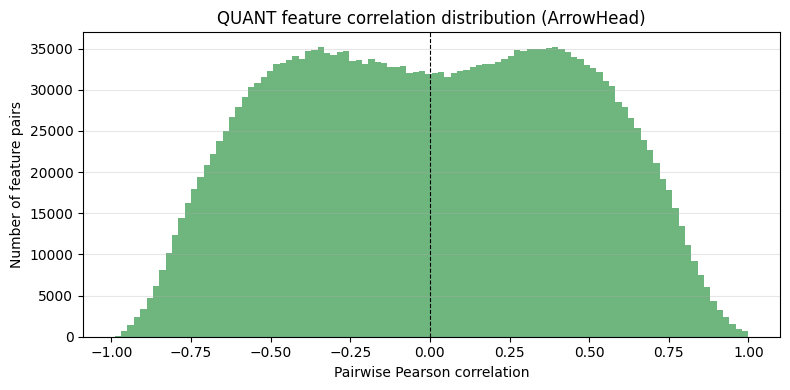

mean |corr|: 0.385
fraction of pairs with |corr| > 0.8: 0.036


In [6]:
# Pearson correlation between every pair of features (on the training set).
# Drop constant features first, since their correlation is undefined (NaN).
non_constant = F_train.std(axis=0) > 0
F_nc = F_train[:, non_constant]
print(f"{non_constant.sum()} / {F_train.shape[1]} non-constant features")

corr = np.corrcoef(F_nc, rowvar=False)
# Keep only the upper triangle (unique pairs, exclude self-correlations).
iu = np.triu_indices_from(corr, k=1)
pair_corr = corr[iu]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pair_corr, bins=100, color="#55A868", alpha=0.85)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Pairwise Pearson correlation")
ax.set_ylabel("Number of feature pairs")
ax.set_title(f"QUANT feature correlation distribution ({DATASET})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"mean |corr|: {np.abs(pair_corr).mean():.3f}")
print(f"fraction of pairs with |corr| > 0.8: {(np.abs(pair_corr) > 0.8).mean():.3f}")

### Correlation dendrogram

Cluster the features hierarchically using correlation distance (`1 - |corr|`, so both strongly positive and negative correlations group together). Deep, dense merges low on the y-axis mean large groups of near-duplicate features. The tree is truncated to the top clusters for readability.

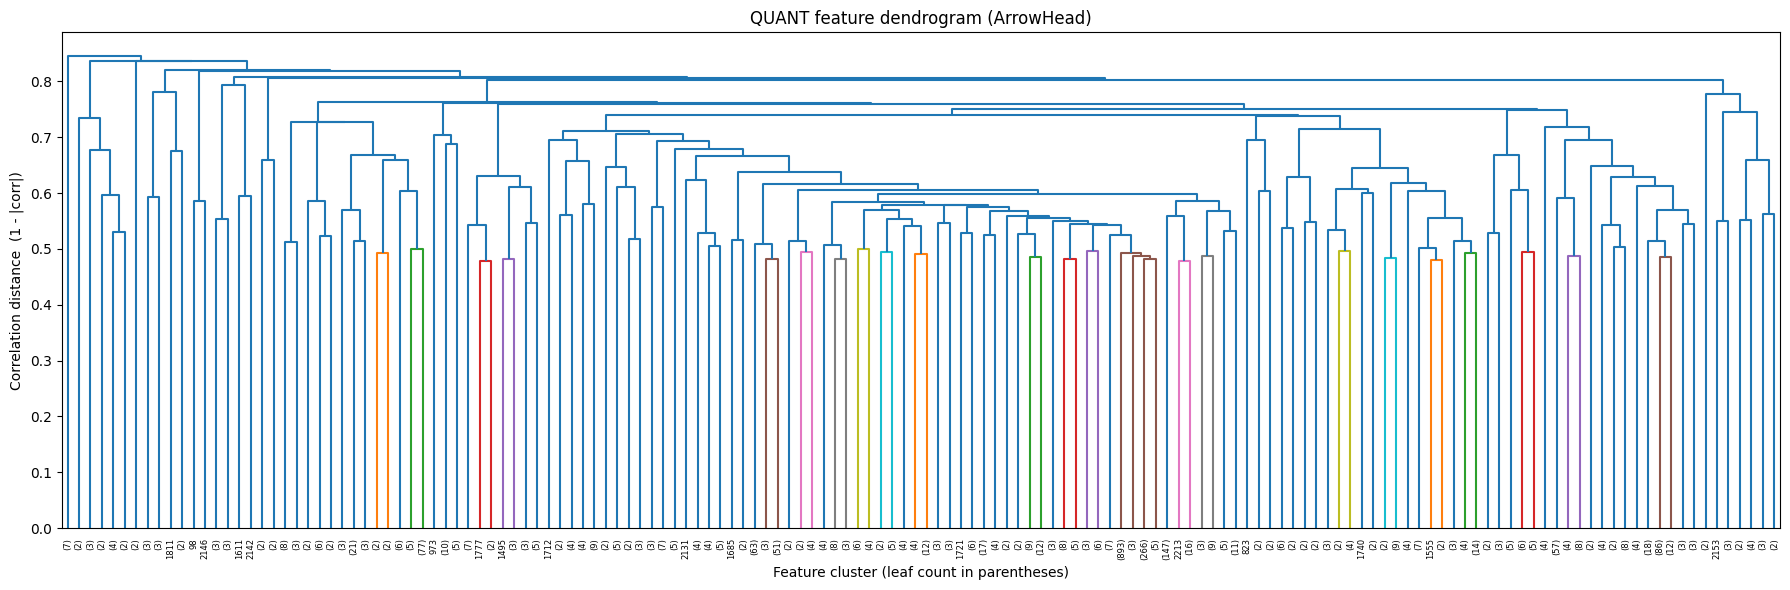

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Correlation distance: 0 = identical, 1 = uncorrelated. Reuse `corr` from above.
dist = 1.0 - np.abs(corr)
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2  # enforce exact symmetry for squareform
condensed = squareform(dist, checks=False)

Z = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(
    Z,
    truncate_mode="lastp",   # show only the top clusters
    p=150,
    show_leaf_counts=True,
    color_threshold=0.5,
    ax=ax,
)
ax.set_xlabel("Feature cluster (leaf count in parentheses)")
ax.set_ylabel("Correlation distance  (1 - |corr|)")
ax.set_title(f"QUANT feature dendrogram ({DATASET})")
ax.tick_params(axis="x", labelsize=6)
plt.tight_layout()
plt.show()

## 5. Feature reduction: cluster representatives

Cut the correlation dendrogram at a distance threshold to group near-duplicate features, then keep a single representative per cluster (the one with the strongest univariate ANOVA-F association with the target). This removes redundancy in a *stable* way — unlike tree/L1 importance, it doesn't depend on noisy multivariate estimates from only 36 rows. We then retrain ExtraTrees on the reduced set and compare.

In [8]:
from scipy.cluster.hierarchy import fcluster
from sklearn.feature_selection import f_classif

# `corr`/`Z` were built on the non-constant features; map back to original columns.
nc_idx = np.where(non_constant)[0]

# Univariate strength of each non-constant feature vs the target (shared across thresholds).
f_scores, _ = f_classif(F_train[:, nc_idx], y_train)
f_scores = np.nan_to_num(f_scores)


def select_representatives(threshold):
    """Cut the dendrogram at `threshold` and keep the top-F-score feature per cluster.

    A `threshold` of 0 means no reduction: every original column is returned.
    Returns original-column indices (into F_train / F_test).
    """
    if threshold <= 0:
        return np.arange(F_train.shape[1])
    clusters = fcluster(Z, t=threshold, criterion="distance")
    rep_local = [
        members[np.argmax(f_scores[members])]
        for members in (np.where(clusters == c)[0] for c in np.unique(clusters))
    ]
    return np.sort(nc_idx[rep_local])


# Sweep a range of correlation-distance thresholds:
#   small threshold  -> only near-identical features merged -> many features kept
#   large threshold  -> looser clusters                     -> few features kept
THRESHOLDS = [0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6]
SEEDS = range(20)

# Cluster selection is deterministic, so compute it once per threshold.
selections = {t: select_representatives(t) for t in THRESHOLDS}


def cv_accuracy(cols):
    """Mean/std test accuracy of ExtraTrees over SEEDS, trained on the given columns."""
    accs = []
    for seed in SEEDS:
        clf_s = ExtraTreesClassifier(n_estimators=400, n_jobs=-1)
        clf_s.fit(F_train[:, cols], y_train)
        accs.append(accuracy_score(y_test, clf_s.predict(F_test[:, cols])))
    return float(np.mean(accs)), float(np.std(accs))


rows = []
for t in THRESHOLDS:
    cols = selections[t]
    mean_acc, std_acc = cv_accuracy(cols)
    rows.append({"threshold": t, "n_features": len(cols), "acc_mean": mean_acc, "acc_std": std_acc})

# Full feature set, also averaged over the same seeds for a fair reference.
full_mean, full_std = cv_accuracy(np.arange(F_train.shape[1]))

sweep = pl.DataFrame(rows)
print(f"Full model: {F_train.shape[1]} features -> acc {full_mean:.4f} ± {full_std:.4f} "
      f"(over {len(SEEDS)} seeds)\n")
sweep

Full model: 2242 features -> acc 0.8254 ± 0.0127 (over 20 seeds)



threshold,n_features,acc_mean,acc_std
f64,i64,f64,f64
0.0,2242,0.827143,0.014666
0.01,2081,0.819429,0.016502
0.02,1966,0.821429,0.014777
0.05,1672,0.814,0.015802
0.1,1261,0.798286,0.011725
…,…,…,…
0.2,756,0.779429,0.011051
0.3,431,0.764857,0.012555
0.4,239,0.732571,0.018657


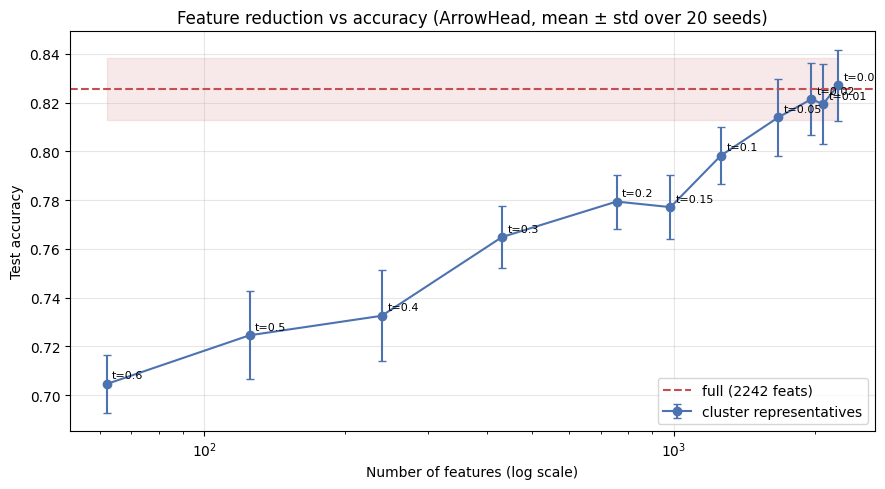

In [9]:
# Accuracy (mean ± std over seeds) vs number of retained features across thresholds.
fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    sweep["n_features"], sweep["acc_mean"], yerr=sweep["acc_std"],
    fmt="o-", color="#4C72B0", capsize=3, label="cluster representatives",
)
for t, n, a in zip(sweep["threshold"], sweep["n_features"], sweep["acc_mean"]):
    ax.annotate(f"t={t}", (n, a), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(full_mean, color="#C44E52", ls="--", label=f"full ({F_train.shape[1]} feats)")
ax.fill_between(
    sweep["n_features"], full_mean - full_std, full_mean + full_std,
    color="#C44E52", alpha=0.12,
)
ax.set_xscale("log")
ax.set_xlabel("Number of features (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title(f"Feature reduction vs accuracy ({DATASET}, mean ± std over {len(SEEDS)} seeds)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()